In [3]:
import pandas as pd
import ir_datasets
from src.data import DATA_DIR_INTERIM, DATA_DIR_RAW
from topic_gen.evaluate import QrelsEvaluator, ROSKendallTau, ROSRBO, binarize_qrels, load_runs_from_path, ARP

from src.data import load_qrels_from_path

from topic_gen import logger
logger.setLevel("DEBUG")

## **Distinguishability**: How well can the generated qrels based on generated topics differentiate between retrieval systems?

In [6]:
from ir_measures import nDCG, MAP, RBP

runs = load_runs_from_path(DATA_DIR_RAW / "datasets" / "robust" / "trec-2004-runs")

In [1]:
# Load generated qrels from path
BASE_DIR = DATA_DIR_INTERIM / "qrels-robust-topics-generated"

predictions, names, metadata = load_qrels_from_path(BASE_DIR)

# binarize qrels
predictions = [binarize_qrels(qrels) for qrels in predictions]

NameError: name 'DATA_DIR_INTERIM' is not defined

In [8]:
reference = binarize_qrels(ir_datasets.load(
    "disks45/nocr/trec-robust-2004").qrels_iter())

### Scatter Plot

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
res = QrelsEvaluator.experiment(
    predictions=predictions[:1],
    references=reference,
    measures=[ARP(runs, measures=[nDCG@10]),
              ROSKendallTau(runs, measures=[nDCG@10])],
    # bootstrap=20,
    names=names[:1]
)

[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 7/2944 qrels in references but not in predictions.


In [11]:
df = pd.DataFrame(res)
df = df.merge(metadata, left_on="name", right_on="date")

In [12]:
def plot_system_correlation(df):
    def _split_arp_measure(row):
        measure = row["measure"].replace("ARP(", "").replace(")", "")
        parts = measure.split("_")
        return {
            "measure": parts[0],
            "condition": parts[1],
            "system": str(parts[2])
        }

    def _plot_ros(df, tau= None):
        df = df.pivot(index="system", columns="condition", values="value")
        sns.scatterplot(data=df, x="base", y="exp", color="black")

        # title
        plt.title("")
        plt.xlabel("Reference Qrels")
        plt.ylabel("Predicted Qrels")

        # add tau annotation
        if tau:
            plt.annotate(
                f"Kendall's $\\tau$ = { round(tau, 3) }",
                xy=(0.05, 0.95),
                xycoords='axes fraction',
                fontsize=12,
                ha='left',
                va='top'
            )

    arp = df[df["measure"].str.startswith("ARP")].copy()
    arp[["measure", "condition", "system"]] = arp.apply(
        _split_arp_measure, axis=1, result_type="expand")

    tau = df[df["measure"].str.startswith("ROSKendallTau")].copy()

    for idx, topic in arp.groupby("name"):
        tau = tau[tau["name"] == topic["name"].iloc[0]].iloc[0]["value"]
        _plot_ros(topic, tau)


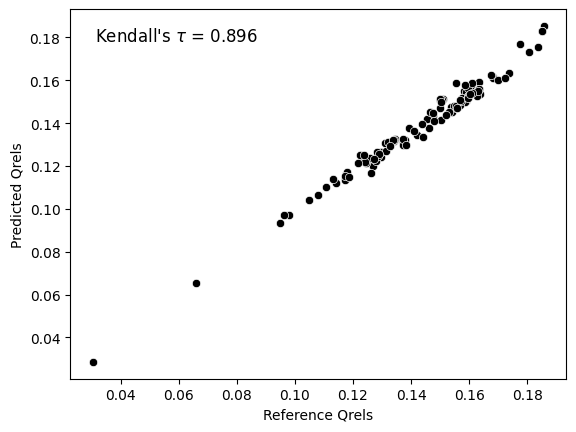

In [13]:
plot_system_correlation(df)

### ROS table

In [14]:
# Load generated qrels from path
BASE_DIR = DATA_DIR_INTERIM / "qrels-robust-topics-generated"
predictions, names, metadata = load_qrels_from_path(BASE_DIR)

# binarize qrels
predictions = [binarize_qrels(qrels) for qrels in predictions]

# reference qrels
reference = binarize_qrels(ir_datasets.load(
    "disks45/nocr/trec-robust-2004").qrels_iter())

In [ ]:
res = QrelsEvaluator.experiment(
    predictions=predictions,
    references=reference,
    measures=[ROSKendallTau(runs, measures=[nDCG@10, MAP@100]),
              ROSRBO(runs, measures=[nDCG@10, MAP@100], p=0.6, k=100)],
    # bootstrap=20,
    names=names
)

[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 12/2939 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 21/2930 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 8/2943 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 28/2923 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 11/2940 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 4/2947 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 10/2941 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 25/2926 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 24/2927 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345)

In [95]:
table = pd.DataFrame(res)

In [96]:
table = table.pivot(index="name", columns="measure", values="value").round(3)[
    ["ROSKendallTau(nDCG@10)", "ROSRBO(nDCG@10)", "ROSKendallTau(AP@100)", "ROSRBO(AP@100)"]]

In [97]:
table = table.merge(metadata, left_on="name", right_on="date")

In [98]:
table[["model", "topics_model", "topics_prompt", "topics_nqueries", "topics_ndocsneg", "topics_ndocspos",
       "ROSKendallTau(nDCG@10)", "ROSRBO(nDCG@10)", "ROSKendallTau(AP@100)", "ROSRBO(AP@100)"]]

,model,topics_model,topics_prompt,topics_nqueries,topics_ndocsneg,topics_ndocspos,ROSKendallTau(nDCG@10),ROSRBO(nDCG@10),ROSKendallTau(AP@100),ROSRBO(AP@100)
0,qwen3-30B-no-think,qwen3-14B-no-think,trec,1.0,3.0,1.0,0.8,0.577,1.0,0.977
1,gpt-oss-120B,qwen3-30B-no-think,trec-docs-rel,5.0,3.0,3.0,0.8,0.577,0.8,0.577
